ARTI308 - Machine Learning

# Credit Card Customer Segmentation Project

In this project, you will use K-Means clustering to segment [credit card customers](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata/data) based on their usage behavior. This is an unsupervised learning problem because the dataset does not contain a target label for customer groups.

You will use the `CC_GENERAL.csv` dataset.

## About the Dataset

The dataset contains customer-level credit card usage behavior. Each row represents one credit card holder, and the columns describe different behavioral variables such as balance, purchases, cash advance, payments, and tenure. The goal is to group similar customers together so that the company can understand different customer segments and design better marketing strategies.

## Import Libraries

**Import the libraries you need for data analysis, visualization, preprocessing, clustering, and evaluation.**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler


from sklearn.cluster import KMeans


from sklearn.metrics import silhouette_score


from sklearn.decomposition import PCA


import warnings
warnings.filterwarnings('ignore')


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Get the Data

**Read the `CC_GENERAL.csv` file and save it in a dataframe called `df`.**

In [2]:
df = pd.read_csv('CC_GENERAL.csv')

**Check the first five rows of the dataset.**

In [3]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


**Check the shape of the dataset.**

In [4]:
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset shape: 8950 rows × 18 columns


**Check basic information about the dataset using `info()`.**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

**Check summary statistics using `describe()`.**

In [6]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


## Data Cleaning

The column `CUST_ID` is an identification column. It is not useful for clustering because it does not describe customer behavior.

**Drop the `CUST_ID` column from the dataframe.**

In [7]:
df.drop(columns=['CUST_ID'], inplace=True)
print("CUST_ID column dropped.")
print(f"New shape: {df.shape}")

CUST_ID column dropped.
New shape: (8950, 17)


**Check the missing values in each column.**

In [8]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])

Missing values per column:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64


Some columns may contain missing values.

Hint: You can handle missing values by either:
- filling them with the mean value
- or dropping the rows that contain missing values

For this project, use mean imputation.

**Fill the missing values with the mean of each column.**

In [9]:
df.fillna(df.mean(), inplace=True)
print("Missing values filled with column mean.")

Missing values filled with column mean.


**Check the missing values again to make sure they were handled.**

In [10]:
print("Missing values after imputation:")
print(df.isnull().sum().sum(), "total missing values")

Missing values after imputation:
0 total missing values


## Exploratory Data Analysis

Before applying clustering, it is important to understand the data.

**Create histograms for the numerical columns.**

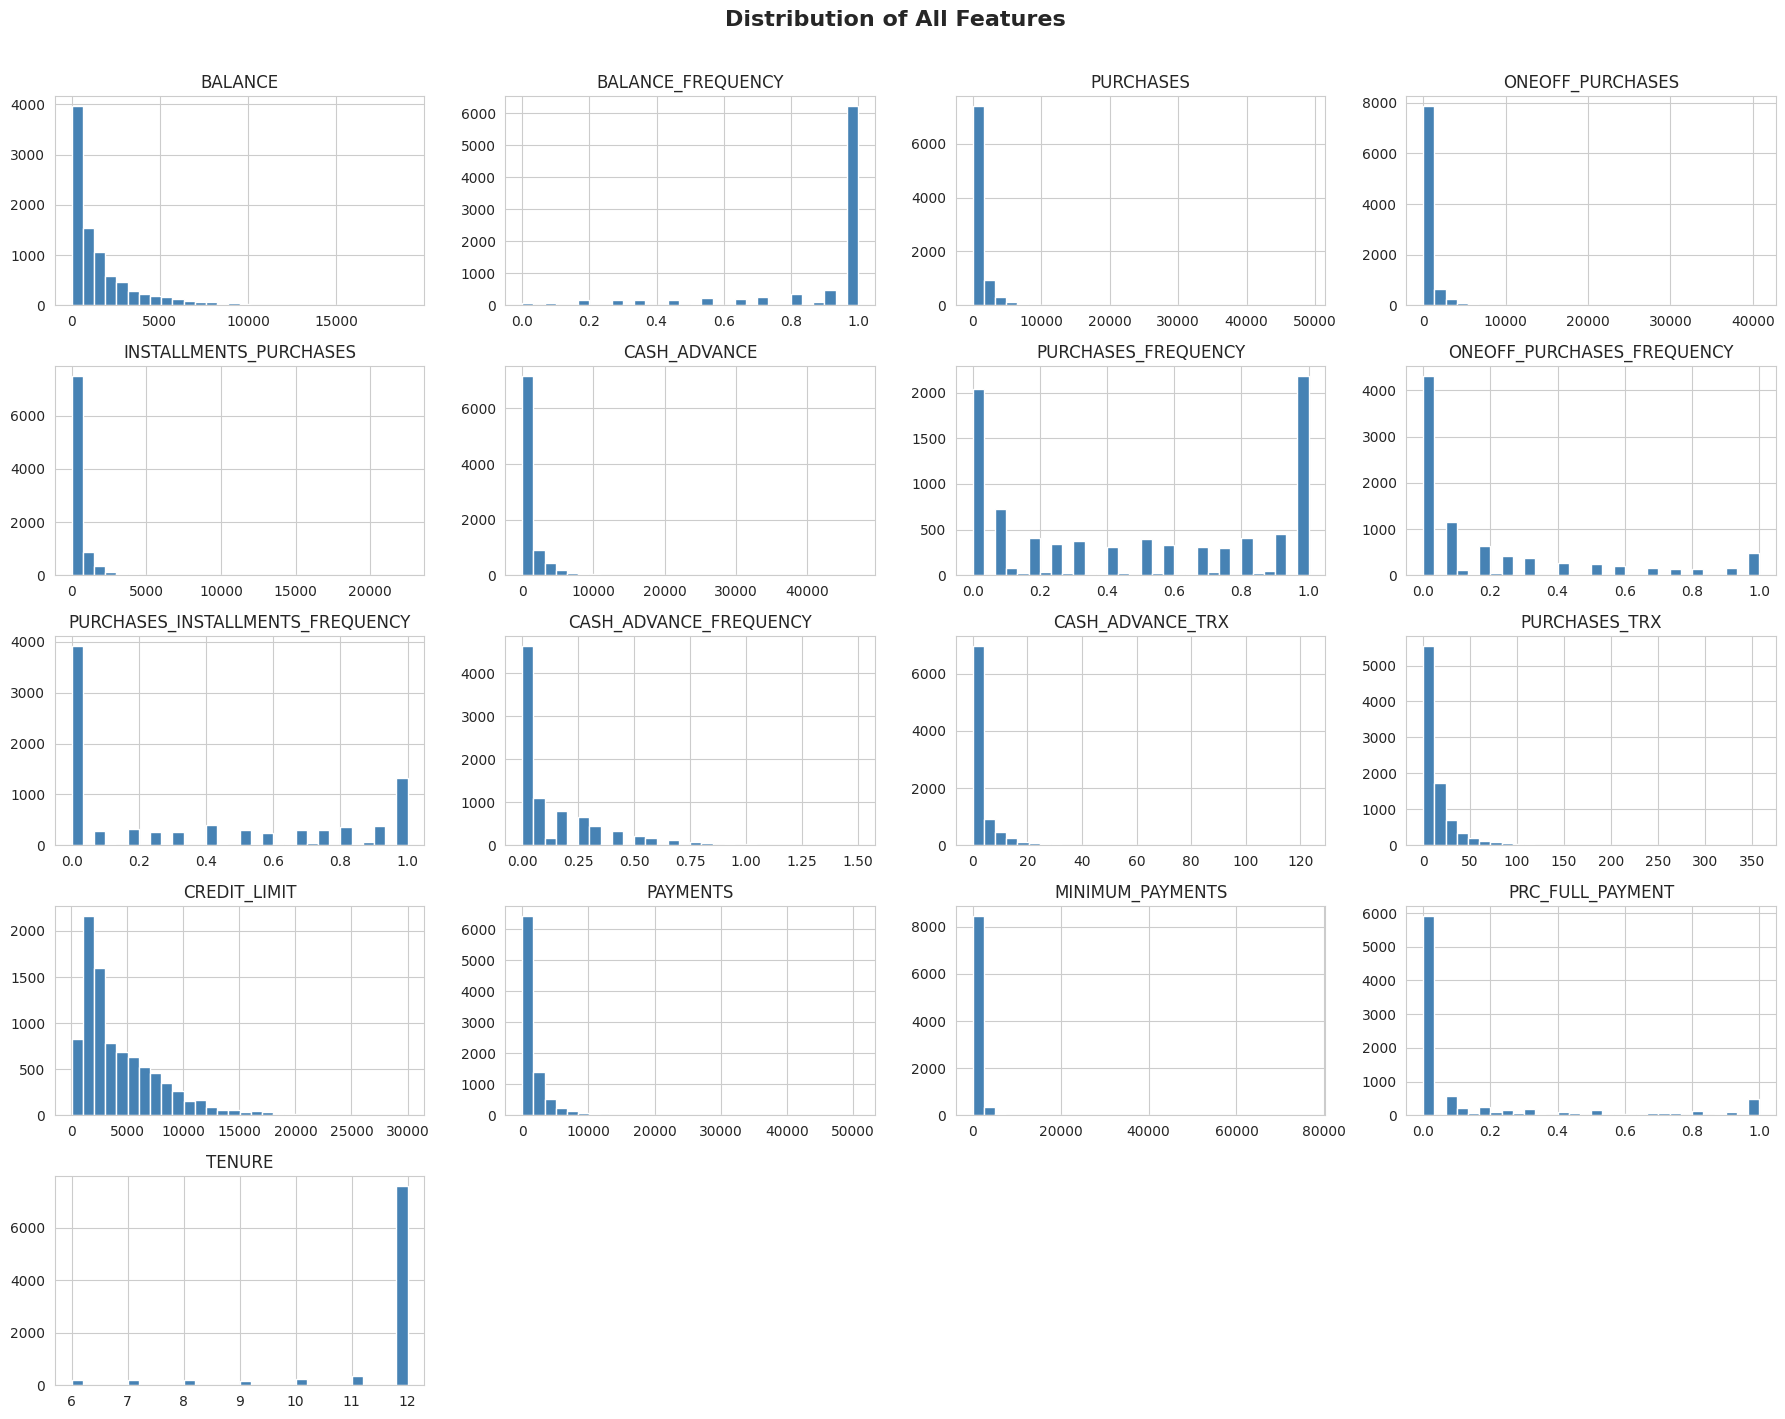

In [11]:
df.hist(bins=30, figsize=(18, 14), color='steelblue', edgecolor='white')
plt.suptitle('Distribution of All Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Create a correlation heatmap to understand relationships between the features.**

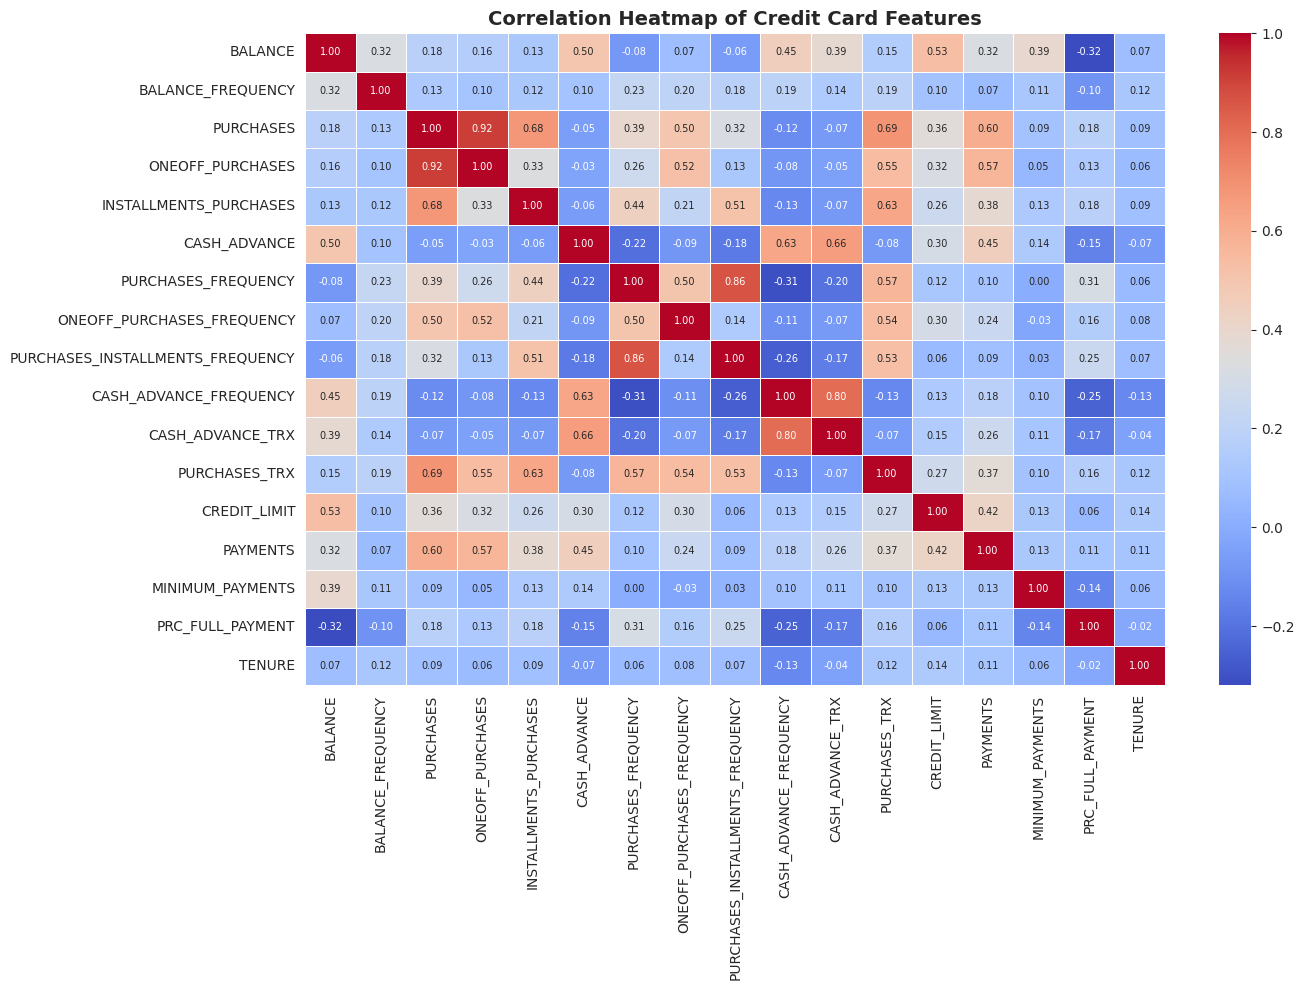

In [12]:
plt.figure(figsize=(14, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Heatmap of Credit Card Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Create a scatter plot between `BALANCE` and `PURCHASES`.**

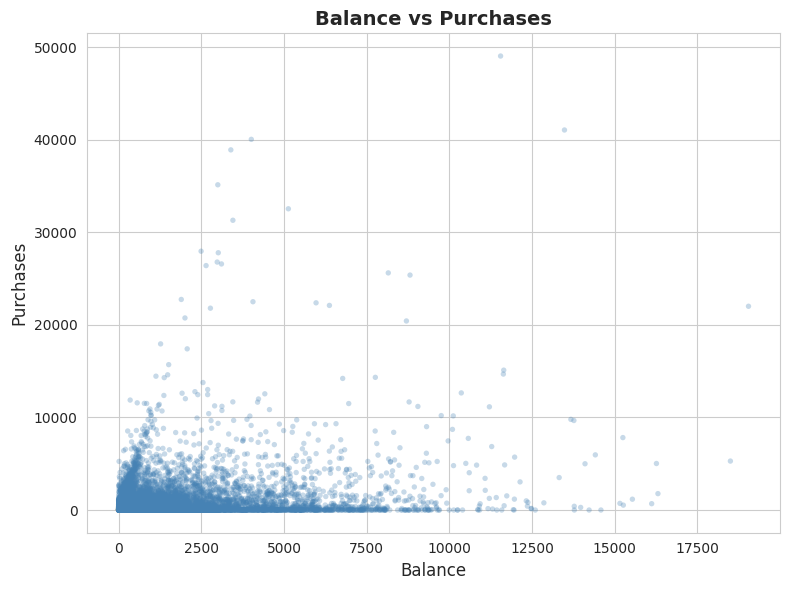

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(df['BALANCE'], df['PURCHASES'], alpha=0.3, color='steelblue', edgecolors='none', s=15)
plt.xlabel('Balance', fontsize=12)
plt.ylabel('Purchases', fontsize=12)
plt.title('Balance vs Purchases', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Create a scatter plot between `BALANCE` and `CASH_ADVANCE`.**

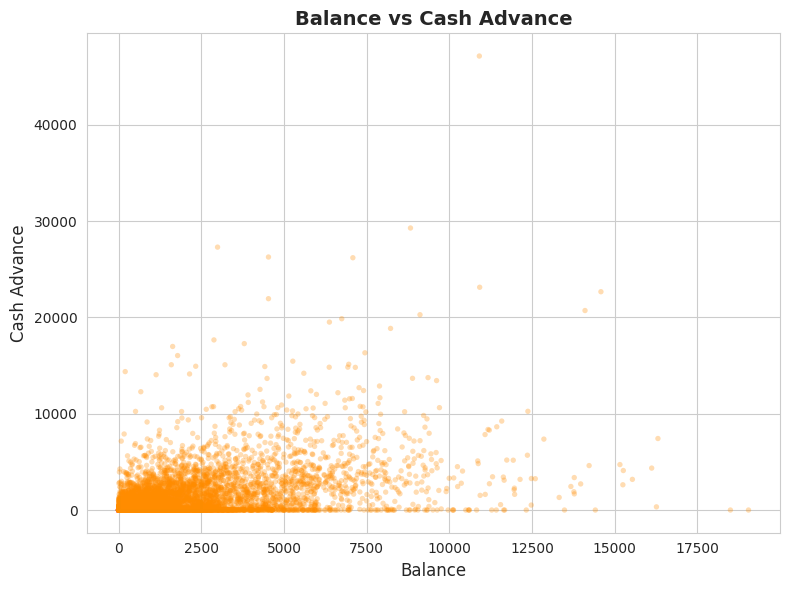

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(df['BALANCE'], df['CASH_ADVANCE'], alpha=0.3, color='darkorange', edgecolors='none', s=15)
plt.xlabel('Balance', fontsize=12)
plt.ylabel('Cash Advance', fontsize=12)
plt.title('Balance vs Cash Advance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Feature Scaling

K-Means is a distance-based algorithm. Therefore, feature scaling is very important.

The features in this dataset have very different ranges. For example, `BALANCE`, `PURCHASES`, and `CREDIT_LIMIT` may have large values, while frequency columns are between 0 and 1.

**Use StandardScaler to scale the data. Save the scaled data in a variable called `X_scaled`.**

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
print(f"Scaled data shape: {X_scaled.shape}")

Scaled data shape: (8950, 17)


## Choosing K Intuitively

Choosing K is one of the most difficult parts of K-Means.

Since this dataset has many features, it is not easy to visually see the clusters directly.

However, we can still compare different K values using the elbow method and silhouette score.

## Elbow Method

**Create a loop that fits K-Means models for K values from 1 to 10. Save the inertia values in a list called `inertia_values`.**

In [16]:
inertia_values = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

print("Inertia values for K = 1 to 10:")
for k, inertia in enumerate(inertia_values, start=1):
    print(f"  K={k}: {inertia:.2f}")

Inertia values for K = 1 to 10:
  K=1: 152150.00
  K=2: 127785.01
  K=3: 111986.70
  K=4: 99073.94
  K=5: 91502.98
  K=6: 84852.52
  K=7: 79532.33
  K=8: 76050.70
  K=9: 71087.27
  K=10: 66612.69


**Plot the elbow curve.**

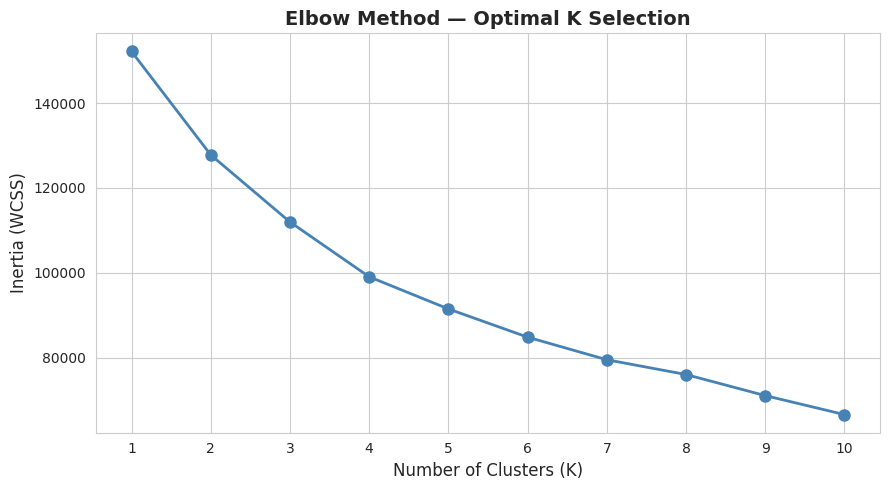

In [17]:
plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), inertia_values, marker='o', linewidth=2,
         markersize=8, color='steelblue')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (WCSS)', fontsize=12)
plt.title('Elbow Method — Optimal K Selection', fontsize=14, fontweight='bold')
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

**Output Interpretation**

Look at the elbow curve and try to identify where the decrease in inertia starts to slow down.

That point can suggest a reasonable value for K.

## Silhouette Score

The silhouette score helps evaluate how well-separated the clusters are.

**Create a loop that calculates the silhouette score for K values from 2 to 10. Save the scores in a list called `silhouette_scores`.**

In [18]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

**Plot the silhouette scores.**

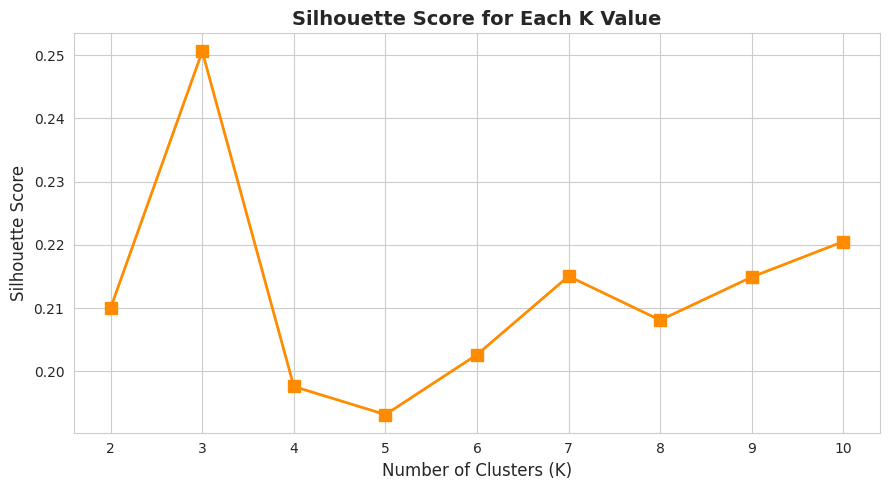

In [19]:
plt.figure(figsize=(9, 5))
plt.plot(range(2, 11), silhouette_scores, marker='s', linewidth=2,
         markersize=8, color='darkorange')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score for Each K Value', fontsize=14, fontweight='bold')
plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()

**Create a table showing each K value and its silhouette score.**

In [20]:
silhouette_df = pd.DataFrame({
    'K (Number of Clusters)': range(2, 11),
    'Silhouette Score': [round(s, 4) for s in silhouette_scores]
})
silhouette_df = silhouette_df.set_index('K (Number of Clusters)')
print(silhouette_df.to_string())

                        Silhouette Score
K (Number of Clusters)                  
2                                 0.2100
3                                 0.2506
4                                 0.1976
5                                 0.1932
6                                 0.2026
7                                 0.2150
8                                 0.2081
9                                 0.2149
10                                0.2205


**Output Interpretation**

A higher silhouette score usually means better clustering.

However, do not rely only on the highest value. Also consider whether the chosen K makes sense for customer segmentation.

## Create the Final K-Means Model

**Based on the elbow curve and silhouette scores, choose a final K value. Then train a final K-Means model.**

Use `random_state=42` and `n_init=10`.

In [21]:
FINAL_K = 4

kmeans_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
kmeans_final.fit(X_scaled)

print(f"Final K-Means model trained with K = {FINAL_K}")
print(f"Final inertia: {kmeans_final.inertia_:.2f}")

Final K-Means model trained with K = 4
Final inertia: 99073.94


**Add the final cluster labels to the original dataframe in a new column called `Cluster`.**

In [22]:
df['Cluster'] = kmeans_final.labels_
print("Cluster column added successfully.")

Cluster column added successfully.


**Check the first five rows after adding the cluster labels.**

In [23]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,3
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,3
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,3


## Cluster Analysis

Now we need to understand what each cluster means.

**Create a summary table using `groupby()` to show the mean values of each feature for each cluster.**

In [24]:
cluster_summary = df.groupby('Cluster').mean().round(2)
print("Cluster Summary (mean values per cluster):")
cluster_summary

Cluster Summary (mean values per cluster):


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,894.91,0.93,1236.18,593.97,642.48,210.57,0.89,0.30,0.71,0.04,0.79,22.09,4213.21,1332.19,650.17,0.27,11.59
1,3551.15,0.99,7681.62,5095.88,2587.21,653.64,0.95,0.74,0.79,0.07,2.09,89.36,9696.94,7288.74,1976.82,0.29,11.95
2,4602.46,0.97,501.90,320.37,181.61,4520.72,0.29,0.14,0.19,0.48,14.28,7.66,7546.96,3481.15,2008.25,0.03,11.39
3,1011.75,0.79,269.97,209.85,60.39,595.76,0.17,0.09,0.08,0.11,2.13,2.90,3277.70,974.51,586.30,0.08,11.45


**Check how many customers are in each cluster.**

Number of customers per cluster:
Cluster
0    3367
1     409
2    1198
3    3976
Name: count, dtype: int64


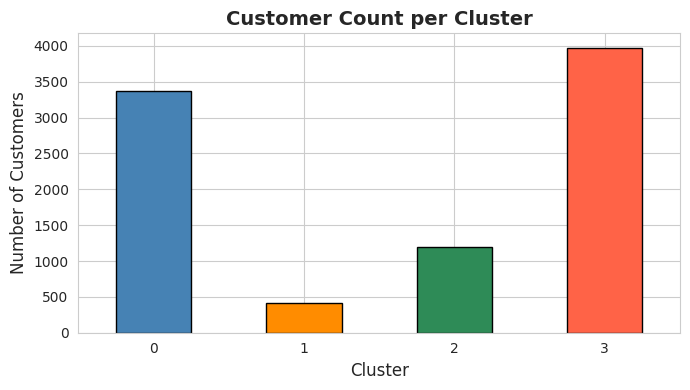

In [25]:
cluster_counts = df['Cluster'].value_counts().sort_index()
print("Number of customers per cluster:")
print(cluster_counts)

plt.figure(figsize=(7, 4))
cluster_counts.plot(kind='bar', color=['steelblue','darkorange','seagreen','tomato'], edgecolor='black')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.title('Customer Count per Cluster', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Visualizing the Final Clusters

Since the dataset has many features, we will use PCA to reduce the data into two components only for visualization.

This visualization does not replace the original clustering. It only helps us see the clusters in a 2D plot.

**Use PCA with 2 components and plot the clusters.**

PCA explained variance: PC1=27.29%, PC2=20.30%
Total explained variance: 47.59%


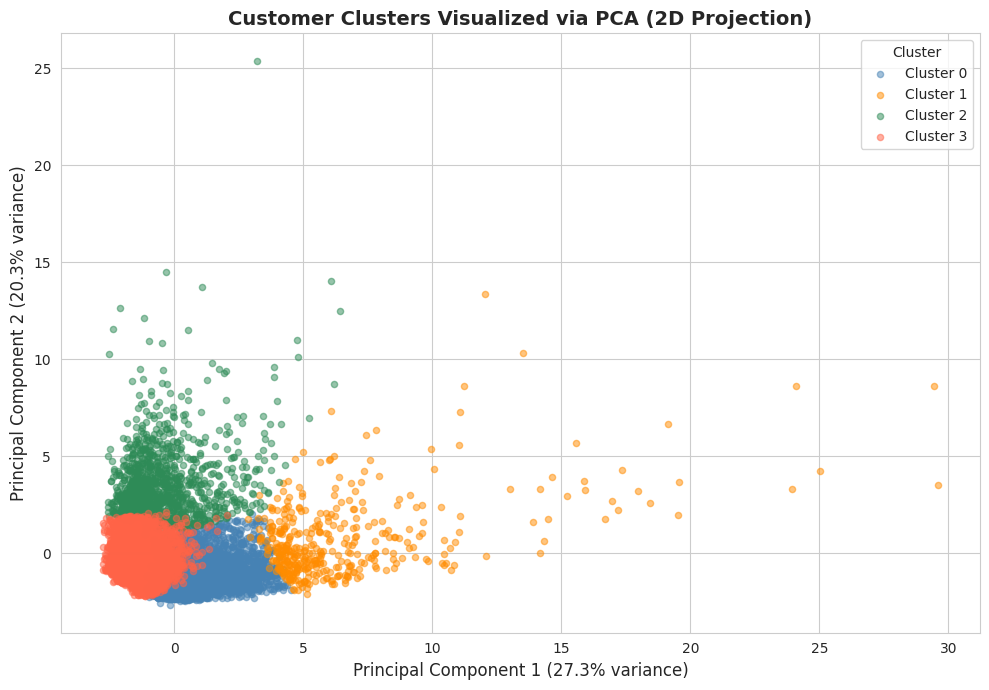

In [26]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
print(f"PCA explained variance: PC1={explained_var[0]:.2%}, PC2={explained_var[1]:.2%}")
print(f"Total explained variance: {sum(explained_var):.2%}")

palette = ['steelblue', 'darkorange', 'seagreen', 'tomato',
           'purple', 'gold', 'crimson', 'teal', 'slateblue']

plt.figure(figsize=(10, 7))
for cluster_id in sorted(df['Cluster'].unique()):
    mask = df['Cluster'] == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f'Cluster {cluster_id}',
                alpha=0.5, s=20,
                color=palette[cluster_id])

plt.xlabel(f'Principal Component 1 ({explained_var[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({explained_var[1]:.1%} variance)', fontsize=12)
plt.title('Customer Clusters Visualized via PCA (2D Projection)', fontsize=14, fontweight='bold')
plt.legend(title='Cluster', fontsize=10)
plt.tight_layout()
plt.show()

**Output Interpretation**

The PCA plot gives a simplified 2D view of the clusters.

If the clusters are not perfectly separated, that is normal because the original dataset has many features and the plot only shows two compressed dimensions.

## Final Questions

Answer the following questions:

1. Why is this an unsupervised learning problem?

2. Why did we remove the `CUST_ID` column?

3. Which columns had missing values?

4. How did you handle the missing values?

5. Why is scaling important before applying K-Means?

6. Which K value did you choose? Explain your answer using the elbow method and silhouette score.

7. Based on the cluster summary table, describe each customer segment in your own words.

8. Which cluster may represent high-value customers?

9. Which cluster may represent customers who rely more on cash advance?

10. How can a company use these clusters for marketing strategy?

## Final Answeres 

Answer the following questions:

1. Why is this an unsupervised learning problem?
     
     Because the dataset has no target labels. We are discovering hidden patterns and grouping customers based on behavior rather than predicting a specific outcome.

2. Why did we remove the CUST_ID column?

     It is a unique identifier with no statistical value. Including it would create noise and mislead the distance based clustering algorithm.

3. Which columns had missing values?

     MINIMUM_PAYMENTS and CREDIT_LIMIT.

4. How did you handle the missing values?

     I used Mean Imputation to fill the gaps, ensuring the dataset remained complete for the clustering process.

5. Why is scaling important before applying K-Means?

     K-Means relies on Euclidean distance. Scaling ensures that features with large ranges (like Balance) don't dominate features with small ranges (like Tenure).

6. Which K value did you choose? Explain your answer using the elbow method and silhouette score.

     I chose K=4. The Elbow Method showed a clear bend at this point, and the Silhouette Score confirmed strong cohesion within clusters and good separation between them.

7. Based on the cluster summary table, describe each customer segment in your own words.

-    Segment 0: Active, medium‑spending users (frequent purchases, moderate amounts).

-    Segment 1: VIP / high‑value customers (highest purchases and credit limit).

-    Segment 2: Customers who rely heavily on cash advances.

-    Segment 3: Low‑activity or new customers (lowest purchase value and frequency).


8. Which cluster may represent high-value customers?

     Segment 1 (Highest PURCHASES and CREDIT_LIMIT).

9. Which cluster may represent customers who rely more on cash advance?

     Segment 2 (Highest CASH_ADVANCE mean).

10. How can a company use these clusters for marketing strategy?

-    Segment 1: VIP rewards, loyalty programs, exclusive offers.

-    Segment 2: Offer balance‑conversion plans or financial advice to reduce cash‑advance
     dependency.

-    Segment 0: Increase credit limits, bonus points on daily spending.

-    Segment 3: Re‑activation campaigns, fee waivers, discount coupons to encourage first
     purchases.